# Week 5 Lab — Introduction to Random Graph Models

This lab develops intuition for random network models by moving from deterministic structure to probabilistic structure. We have five main goals / exercises for today's lab:

1. **Clustering in deterministic and real networks**
   - Compute global and average clustering
   - Compare clustering coefficient for artificial examples
   - Contrast with a real social network
2. **Generating Erdős–Rényi graphs**
   - $\mathcal{G}(n, m)$: fixed number of edges $m$
   - $\mathcal{G}(n, p)$: independent linking probability $p$
   - Visualize structural transitions
3. **Exact probabilities in small networks (n = 3)**
   - Enumerate all possible labeled graphs
   - Compute exact probabilities
   - Derive expected number of edges and degrees
4. **Theoretical vs empirical degree distributions**
   - Show degree distributed as binomial Binomial(n−1, p)
   - Simulate many graphs
   - Compare empirical and theoretical distributions
5. **Real-world deviations**
   - Compare empirical degree distribution to Binomial/Poisson
   - Show how real networks differ from pure randomness

In [ ]:
import numpy as np
import igraph as ig
import matplotlib.pyplot as plt
from scipy.special import comb
import itertools

## Part 1 — Clustering in Deterministic and Real Networks

Before introducing random graphs, we follow class and make small digression to measure clustering in purely deterministic structures. We proceed in three steps:
1. A very small graph (easy to compute by hand)
2. A larger structured deterministic graph (a large network)
3. A real-world social network (Karate Club)

Clustering measures:
- Global clustering (transitivity): Fraction of closed triangles (triples where two of my friends are also friends with each other) among all potential triangles.
- Average local clustering: Average of node-level clustering coefficients.

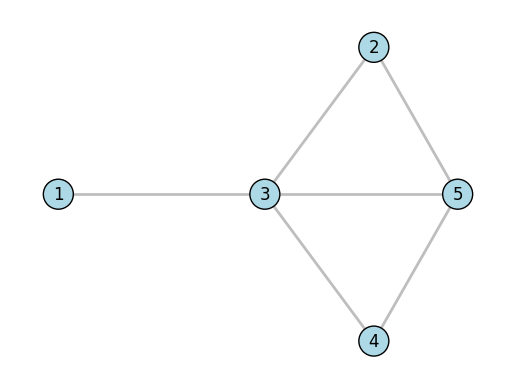

Local clustering without correction: [       nan 1.         0.33333333 1.         0.66666667]
Edges: [(0, 2), (1, 2), (2, 3), (2, 4), (1, 4), (3, 4)]
Local clustering: [0.         1.         0.33333333 1.         0.66666667]
Global clustering: 0.5454545454545454
Average Local clustering: 0.5999999999999999


In [12]:
# Small deterministic graph as in class
g_small = ig.Graph()
g_small.add_vertices(5)
g_small.add_edges([(0,2), (1,2), (3,2), (4,2), (4,1), (4,3)])

# Plot resulting graph
fig, ax = plt.subplots()
ig.plot(g_small, target=ax, vertex_label=range(1,6), vertex_color="lightblue",
        edge_color="gray", vertex_size=30)
plt.show()

# Calculate and print clustering coefficients
local_clustering = np.asarray(g_small.transitivity_local_undirected())
print("Local clustering without correction:", local_clustering)
local_clustering[np.isnan(local_clustering)] = 0  # Replace NaN with 0 for vertices with degree < 2
global_clustering = g_small.transitivity_undirected()
print("Edges:", g_small.get_edgelist())
print("Local clustering:", local_clustering)
print("Global clustering:", global_clustering)
print("Average Local clustering:", np.mean(local_clustering))


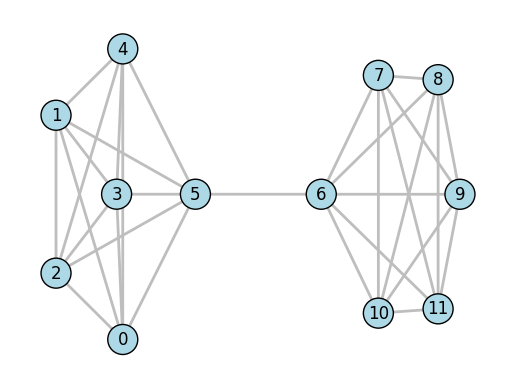

Nodes: 12
Edges: 31
Global clustering: 0.9230769230769231
Average local clustering: 0.9444444444444445


In [13]:
# Two cliques of size 6 connected by one bridge
g_large = ig.Graph()

# Add 12 nodes
g_large.add_vertices(12)

# Clique 1 (0–5)
edges_clique1 = [(i,j) for i in range(6) for j in range(i+1,6)]

# Clique 2 (6–11)
edges_clique2 = [(i,j) for i in range(6,12) for j in range(i+1,12)]

# Bridge edge
bridge = [(5,6)]
g_large.add_edges(edges_clique1 + edges_clique2 + bridge)

# Plot the graph
fig, ax = plt.subplots()
ig.plot(g_large, target=ax, vertex_label=range(g_large.vcount()), vertex_color="lightblue",
        edge_color="gray", vertex_size=30)
plt.show()

print("Nodes:", g_large.vcount())
print("Edges:", g_large.ecount())
print("Global clustering:", g_large.transitivity_undirected())
print("Average local clustering:",
      np.mean(np.asarray(g_large.transitivity_local_undirected())))


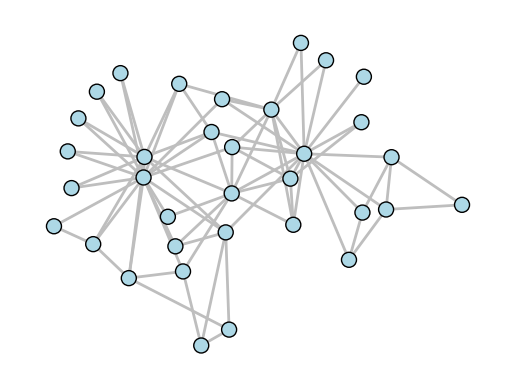

0.13903743315508021
Local clustering without correction: [0.15       0.33333333 0.24444444 0.66666667 0.66666667 0.5
 0.5        1.         0.5        0.         0.66666667 0.
 1.         0.6        1.         1.         1.         1.
 1.         0.33333333 1.         1.         1.         0.4
 0.33333333 0.33333333 1.         0.16666667 0.33333333 0.66666667
 0.5        0.2        0.1969697  0.11029412]
Nodes: 34
Edges: 78
Potential edges: 561.0
Global clustering: 0.2556818181818182
Average local clustering: 0.5706384782076823


In [15]:
# Comparison to real-world Karate club graph
g_karate = ig.Graph.Famous("Zachary")
fig, ax = plt.subplots()
ig.plot(g_karate, target=ax, vertex_color="lightblue",
        edge_color="gray", vertex_size=15)
plt.show()

print(g_karate.density())

local_clustering_karate = np.asarray(g_karate.transitivity_local_undirected())
local_clustering_karate[np.isnan(local_clustering_karate)] = 0  # Replace NaN with 0 for vertices with degree < 2
print("Local clustering without correction:", local_clustering_karate)
print("Nodes:", g_karate.vcount())
print("Edges:", g_karate.ecount())
print("Potential edges:", comb(g_karate.vcount(), 2))
print("Global clustering:", g_karate.transitivity_undirected())
print("Average local clustering:",
      np.mean(local_clustering_karate))


# Part 2 — Erdős–Rényi Random Graphs

Two equivalent constructions:

1. $\mathcal{G}(n, m)$: fixed number of edges $m$
2. $\mathcal{G}(n, p)$: independent linking probability $p$

We visualize for n = 50 and increasing density.

Maximum possible edges: 1225.0


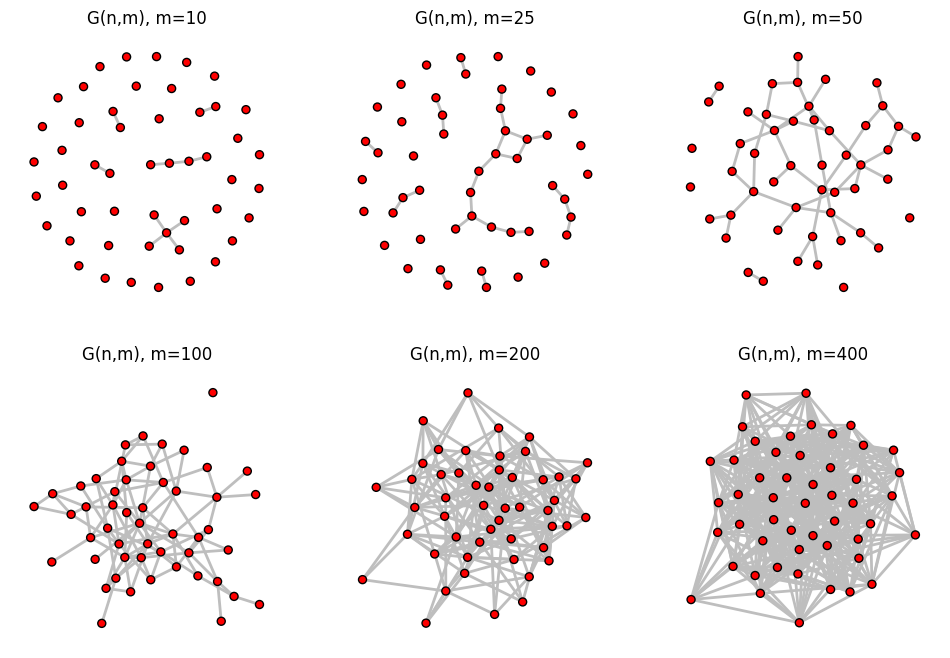

In [16]:
# Node size and maximum allowed edges
n = 50
N = n * (n - 1) / 2  # Total possible edges in an undirected graph without self-loops
print("Maximum possible edges:", N)
edge_counts = [10, 25, 50, 100, 200, 400]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, m in enumerate(edge_counts):
    g = ig.Graph.Erdos_Renyi(n=n, m=m)
    ig.plot(g, target=axes[i//3, i%3], layout=g.layout("fr"),
            vertex_size=8, edge_color="gray")
    axes[i//3, i%3].set_title(f"G(n,m), m={m}")
    axes[i//3, i%3].axis("off")

plt.show()

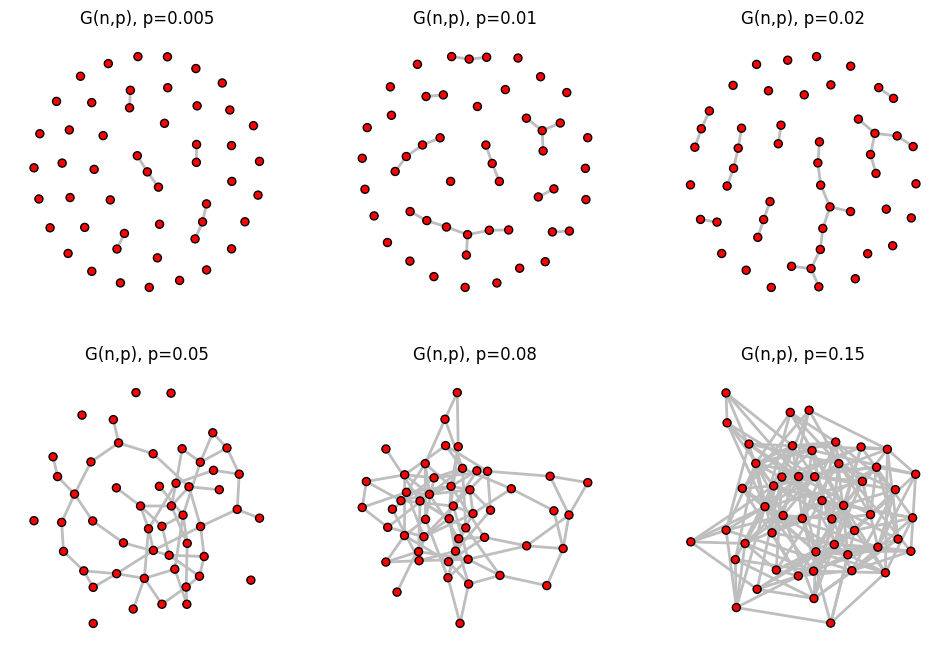

In [17]:
# Node size and edge probability
n = 50
p_values = [0.005, 0.01, 0.02, 0.05, 0.08, 0.15]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, p in enumerate(p_values):
    g = ig.Graph.Erdos_Renyi(n=n, p=p)
    ig.plot(g, target=axes[i//3, i%3], layout=g.layout("fr"),
            vertex_size=8, edge_color="gray")
    axes[i//3, i%3].set_title(f"G(n,p), p={p}")
    axes[i//3, i%3].axis("off")

plt.show()


# Part 3 — Exact Probabilities (n = 3)

With 3 nodes, there are 3 possible edges. Total possible labeled graphs: 2^3 = 8

Under G(n,p), each edge is included independently. Probability of exactly $k\in\{0,1,2\}$ edges: Binomial(2, p)

We compute exact probabilities and expected number of edges.

Total number of networks with n=3: 8
Expected: 2^3 = 2^3 = 8



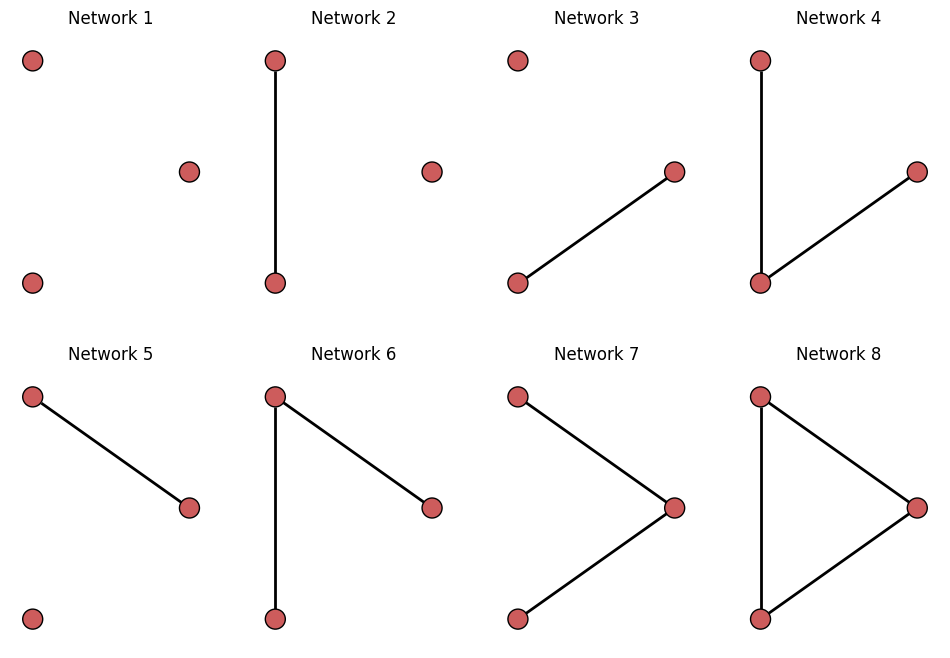

In [19]:
# Generate all possible undirected networks with n nodes.
# 
# For n nodes, there are n(n-1)/2 possible edges.
# Each edge can be present (1) or absent (0).
# Total networks: 2^(n(n-1)/2)
n = 3
num_edges = n * (n - 1) // 2
all_networks = []

# Iterate over all possible edge configurations
counter = 0
fig, ax = plt.subplots(2, 4, figsize=(12, 8))
for edge_config in itertools.product([0, 1], repeat=num_edges):
    # Create adjacency matrix
    A = np.zeros((n, n), dtype=int)
    
    # Fill upper triangle with edge configuration
    edge_idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            A[i, j] = edge_config[edge_idx]
            A[j, i] = edge_config[edge_idx]  # Symmetric for undirected
            edge_idx += 1
    
    all_networks.append(A)

    # Plot and visualize the possible networks using subplots
    g = ig.Graph.Adjacency(A.tolist(), mode=ig.ADJ_UNDIRECTED)
    ig.plot(g, target=ax[counter//4, counter%4], vertex_size=20, vertex_color='indianred', edge_color='black', layout='circle')
    ax[counter//4, counter%4].set_title(f"Network {counter+1}")
    counter += 1

print(f"Total number of networks with n=3: {len(all_networks)}")
print(f"Expected: 2^{3*2//2} = 2^3 = 8\n")

In [20]:
# Calculate probability of k edges for p=0.4
p = 1/3
n = 3
total_edges = int(comb(n,2))

print("Total possible graphs:", 2**total_edges)

# Probability of total sizes of networks
for size in range(total_edges + 1):
    num_graphs = comb(total_edges, size)
    prob_size = num_graphs * (p**size) * ((1-p)**(total_edges-size))
    print(f"P({size} size) =", round(prob_size, 4))

# Probability of k edges
for k in range(n):
    prob = comb(n-1, k)*(p**k)*((1-p)**(total_edges-k))
    print(f"P({k} edges) =", round(prob, 4))

# Expected edges
expected_edges = total_edges * p
print("\nExpected number of edges:", expected_edges)


Total possible graphs: 8
P(0 size) = 0.2963
P(1 size) = 0.4444
P(2 size) = 0.2222
P(3 size) = 0.037
P(0 edges) = 0.2963
P(1 edges) = 0.2963
P(2 edges) = 0.0741

Expected number of edges: 1.0


# Part 4 — Theoretical vs Empirical Degree Distribution

In $G(n,p)$: Degree of node $i$ ~ Binomial $(n-1, p)$

Expected degree: $E[d_i] = (n-1)p$

We simulate many networks and compare empirical results to theoretical binomial predictions.


Empirical degree distribution (normalized): 2.46276


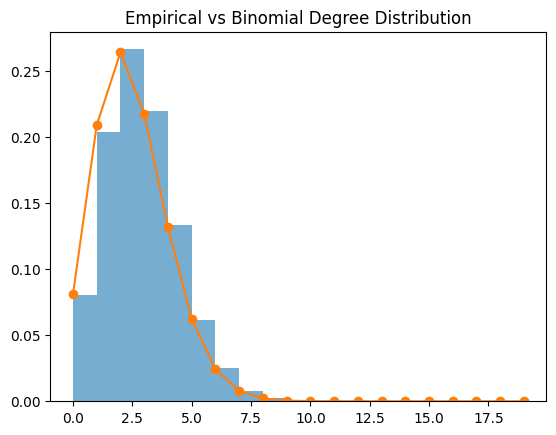

In [21]:
# Simulate many G(n,p) graphs and compare empirical degree distribution to theoretical binomial distribution
n = 50
p = 0.05
num_sim = 1000

degrees = []

for _ in range(num_sim):
    g = ig.Graph.Erdos_Renyi(n=n, p=p)
    degrees.extend(g.degree())

# Empirical histogram
plt.hist(degrees, bins=range(0,20), density=True, alpha=0.6)
print("Empirical degree distribution (normalized):", np.mean(degrees))

# Theoretical binomial
k_vals = np.arange(0,20)
binom_probs = [comb(n-1,k)*(p**k)*((1-p)**(n-1-k)) for k in k_vals]

plt.plot(k_vals, binom_probs, 'o-')
plt.title("Empirical vs Binomial Degree Distribution")
plt.show()


# Part 5 — Real Networks

We compare:

• Karate Club degree distribution
• Binomial prediction with same n and p

Real networks often:
- Have heavier tails
- Show hubs
- Deviate from Poisson approximation

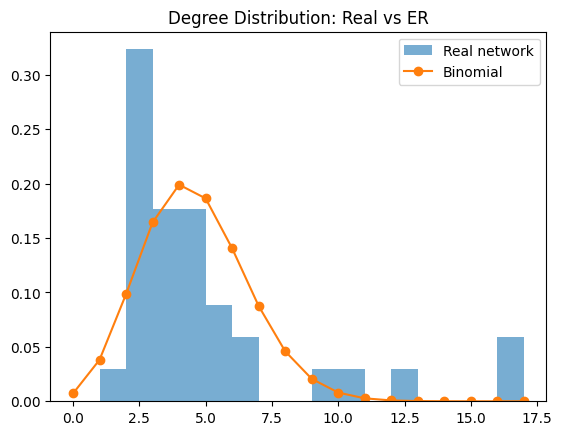

In [22]:
# Compare degree distribution of real-world network to ER model with same n and p
g_real = ig.Graph.Famous("Zachary")

n_real = g_real.vcount()
m_real = g_real.ecount()
p_real = (2*m_real)/(n_real*(n_real-1))

deg_real = g_real.degree()

plt.hist(deg_real, bins=range(0, max(deg_real)+1),
         density=True, alpha=0.6, label="Real network")

# Binomial approximation
k_vals = np.arange(0, max(deg_real)+1)
binom_probs = [comb(n_real-1,k)*(p_real**k)*((1-p_real)**(n_real-1-k))
               for k in k_vals]

plt.plot(k_vals, binom_probs, 'o-', label="Binomial")

plt.legend()
plt.title("Degree Distribution: Real vs ER")
plt.show()
